# Сравнение манипулирования согласно моделям и манипулирования с помощью LLM

Докучаев Алексей Евгеньевич \
2026 г.

# 1. Введение

## 1.1 Мотивация

Теория коллективного выбора (Social Choice Theory) изучает, как индивидуальные предпочтения агентов агрегируются в коллективное решение. Центральный вопрос этой теории: **существует ли "идеальное" правило голосования?**

Спойлер - нет, этот ответ получен с помощью двух фундаментальных результатов:

- **Теорема Эрроу** (1951): не существует правила агрегирования предпочтений, одновременно удовлетворяющего условиям универсальности, единогласия (принцип Парето), независимости от посторонних альтернатив и недиктаторности⁽¹⁾

- **Теорема Гиббарда - Саттертуэйта** (1973, 1975): любая недиктаторская процедура голосования с тремя и более альтернативами, результат которой - единственный победитель, **манипулируема** - то есть существует ситуация, в которой хотя бы один избиратель может улучшить для себя исход, проголосовав неискренне⁽²⁾⁽³⁾

Раз манипулирование неизбежно, возникает естественный вопрос: **насколько** различные правила подвержены манипулированию? Можно ли количественно измерить степень манипулируемости и сравнить правила между собой?

Этот вопрос был впервые поставлен Келли (1993)⁽⁴⁾ и развит Алескеровым и Курбановым (1999)⁽⁵⁾, которые предложили ряд индексов для оценки степени и эффективности манипулирования

## 1.2 Цели проекта

В данном проекте мы:

1. **Реализуем 7 правил голосования** и вычислим для них вероятностные характеристики манипулируемости (индексы Келли, свободы манипулирования, эффективности манипулирования)

2. **Исследуем способности LLM** (Large Language Model) выступать в роли стратегического агента - находить выгодные манипуляции в конкретных ситуациях голосования

3. **Сравним результаты** классических алгоритмов полного перебора с выводами языковой модели

## 1.3 Структура работы

- **Раздел 2** - теоретическая база: определения, правила, индексы
- **Раздел 3** - программная реализация правил голосования
- **Раздел 4** - вычисление индексов манипулируемости
- **Раздел 5** - эксперименты с LLM (Claude)
- **Раздел 6** - сравнительный анализ
- **Раздел 7** - выводы

# 2. Теоретическая база

## 2.1 Основные обозначения

Пусть имеется:
- $A = \{a_1, a_2, \ldots, a_m\}$ - множество из $m$ альтернатив ($m > 2$);
- $N = \{1, 2, \ldots, n\}$ - множество из $n$ избирателей (участников голосования);
- $P_i$ - **предпочтение** избирателя $i$ на множестве $A$, представляющее собой линейный порядок (удовлетворяет свойствам антирефлексивности, транзитивности, связности)⁽⁵⁾;
- $\vec{P} = (P_1, P_2, \ldots, P_n)$ - **профиль** предпочтений всех избирателей;
- $F: \mathbf{L}^n \to \mathbf{A}$ - **функция коллективного выбора**, отображающая профиль в подмножество выигравших альтернатив, где $\mathbf{L}$ - множество всех линейных порядков на $A$, а $\mathbf{A} = 2^A \setminus \{\varnothing\}$ - множество всех непустых подмножеств $A$⁽¹⁵⁾.

Запись $a P_i b$ означает, что избиратель $i$ **строго предпочитает** альтернативу $a$ альтернативе $b$

## 2.2 Определение манипулирования


### Определение 1 (классическое, для однозначного выбора)

Рассмотрим resolute (однозначные) правила голосования $F : L(X)^n \to X$. Пусть $P_i \in L(X)$ — искреннее предпочтение избирателя $i$, а $\tilde{P}_i \in L(X)$ - неискреннее (стратегическое, манипулятивное)⁽¹²⁾

Избиратель $i \in N$ **имеет стимул к манипулированию** при правиле $F$ и профиле $\mathbf{P} \in L(X)$, если существует $\tilde{P}_i \in L(X)$ такое, что⁽²⁾⁽³⁾⁽¹²⁾:

$$F(\tilde{P}_i) \; P_i \; F(\mathbf{P})$$

Иными словами, избиратель $i$, заявив ложное предпочтение $\tilde{P}_i$ вместо истинного $P_i$, получает коллективный выбор, который **лучше для него** (по его истинному предпочтению $P_i$), чем выбор при искренном голосовании

Правило $F$ называется **стратегически защищённым** (strategyproof), если не существует профиля предпочтений, при котором хотя бы один избиратель имеет стимул к манипулированию⁽¹²⁾

\\\\\\\


### Определение 2 (для множественного выбора, по Алескерову и др.)

В случае, когда результат голосования может быть **набором** (подмножеством) альтернатив, а не единственным победителем, необходимо уметь сравнивать подмножества. Для этого вводится **расширенное предпочтение** $EP_i$ на множестве $\mathbf{A}$, определяемое предпочтением $P_i$

Манипулирование имеет место, если существует избиратель $i$ и предпочтение $P_i'$ такие, что⁽⁵⁾:

$$C(\vec{P}_{-i}) \; EP_i \; C(\vec{P})$$

где $\vec{P}_{-i} = (P_1, \ldots, P_{i-1}, P_i', P_{i+1}, \ldots, P_n)$ - профиль с изменённым предпочтением $i$-го участника, а $C(\vec{P})$ и $C(\vec{P}_{-i})$ - коллективные выборы при соответствующих профилях.


> **Примечание.** В данном проекте мы будем использовать оба определения. Для правил с однозначным выбором (когда tie-breaking разрешает ничьи) - Определение 1. Для анализа множественного выбора - Определение 2 с расширением предпочтений по методу **Leximin**⁽⁶⁾

Важно также отметить, что манипулирование может осуществляться не только избирателями (искажение предпочтений), но и организаторами голосования - через выбор правила, набора или порядка кандидатов⁽¹²⁾. В нашем проекте мы сосредоточимся на манипулировании **со стороны избирателей**

## 2.3 Теорема Гиббарда - Саттертуэйта

**Теорема** (Gibbard, 1973; Satterthwaite, 1975). Пусть $|A| \geq 3$ и $F: \mathbf{L}^n \to A$ - сюръективная функция голосования (каждая альтернатива может победить при некотором профиле). Тогда $F$ является **стратегически защищённой** (strategyproof) тогда и только тогда, когда $F$ - **диктатура**⁽²⁾⁽³⁾⁽¹²⁾⁽¹⁵⁾.

Следствие: **любое разумное (недиктаторское) правило голосования манипулируемо**

## 2.4 Правила голосования

В проекте рассматриваются 7 правил голосования. Первые 5 - основные (из учебной программы), последние 2 - дополнительные (из исследования Алескерова и др.⁽⁵⁾)




### 1. Правило относительного большинства (Plurality)

В коллективный выбор входят альтернативы, которые являются **лучшими** (стоят на первом месте) для наибольшего числа избирателей⁽⁵⁾⁽⁷⁾⁽¹⁵⁾:

$$a \in C(\vec{P}) \iff \forall x \in A: \; n^+(a, \vec{P}) \geq n^+(x, \vec{P})$$

где $n^+(a, \vec{P}) = |\{i \in N \mid \forall y \in A: \; a P_i y\}|$ - число избирателей, для которых $a$ - лучшая альтернатива.

**Интуиция:** каждый голосует за своего фаворита, побеждает тот, за кого голосов больше всего

### 2. Правило Борда (Borda count)

Каждой альтернативе $x$ присваивается **ранг Борда** — суммарное число альтернатив, которые $x$ побеждает в предпочтениях каждого избирателя⁽⁵⁾⁽⁷⁾⁽⁸⁾⁽¹⁵⁾:

$$r(x, \vec{P}) = \sum_{i=1}^{n} |\{b \in A : x P_i b\}|$$

В коллективный выбор входят альтернативы с **максимальным** рангом Борда:

$$a \in C(\vec{P}) \iff \forall b \in A: \; r(a, \vec{P}) \geq r(b, \vec{P})$$

**Интуиция:** при $m$ альтернативах первое место получает $m-1$ очко, второе - $m-2$, ..., последнее - 0. Побеждает альтернатива с наибольшей суммой очков

### 3. Правило Кондорсе / простое большинство (Condorcet)

Альтернатива $a$ — **победитель Кондорсе**, если она побеждает **каждую** другую альтернативу в попарном сравнении простым большинством голосов⁽⁷⁾⁽⁹⁾⁽¹⁵⁾:

$$a \text{ — победитель Кондорсе} \iff \forall b \in A \setminus \{a\}: \; |\{i : a P_i b\}| > \frac{n}{2}$$

**Интуиция:** если сравнивать кандидатов попарно по правилу большинства, победитель Кондорсе — это кандидат, который выигрывает у каждого соперника один на один

> **Важно:** победитель Кондорсе существует не всегда (парадокс Кондорсе⁽¹⁵⁾). В случае его отсутствия результат - пустое множество (или используется дополнительное правило)

### 4. Процедура Хэйра (Hare procedure / STV / alternative vote)

Итеративная процедура последовательного исключения⁽⁷⁾⁽¹²⁾⁽¹⁵⁾:

1. Подсчитать число первых мест для каждой альтернативы
2. Исключить альтернативу с **наименьшим** числом первых мест
3. Удалить исключённые альтернативы из всех предпочтений и повторить
4. Процесс продолжается, пока не останется одна альтернатива (или группа с равным числом голосов)

**Интуиция:** аналог системы выборов с перераспределением голосов - наименее популярные кандидаты постепенно выбывают

### 5. Одобряющее голосование (Approval voting, уровня q)

Введём $n^+(a, \vec{P}, q) = |\{i \in N : a \text{ находится среди первых } q \text{ альтернатив в } P_i\}|$⁽⁵⁾.

$$a \in C(\vec{P}) \iff \forall x \in A: \; n^+(a, \vec{P}, q) \geq n^+(x, \vec{P}, q)$$

При $q = 1$ это правило совпадает с Plurality. В этой работе используем $q = 2$

**Интуиция:** каждый избиратель выбирает $q$ лучших альтернатив, побеждает наиболее одобряемая

### 6. Процедура Блэка (Black's procedure) — *бонус*

Если существует победитель Кондорсе — он и является результатом. В противном случае используется правило Борда⁽⁵⁾⁽¹⁰⁾

**Интуиция:** компромисс между критерием Кондорсе и практичным правилом Борда

### 7. Пороговое правило (Threshold rule) — *бонус*

Пусть $v_k(x)$ — число избирателей, для которых альтернатива $x$ стоит на $k$-м месте **снизу** (с конца)⁽⁵⁾.

Альтернатива $x$ **V-доминирует** $y$, если $v_1(x) < v_1(y)$, или $v_1(x) = v_1(y)$ и $v_2(x) < v_2(y)$, и т.д. (лексикографическое сравнение).

В выбор входят альтернативы, **не доминируемые по V**.

**Интуиция:** побеждает альтернатива, которую реже всего ставят на последнее место. при равенстве - на предпоследнее и т.д.

## 2.5 Индексы манипулируемости

Для количественной оценки манипулируемости используются несколько индексов, предложенных в работах Kelly (1993)⁽⁴⁾, Nitzan (1985)⁽¹⁷⁾ и Aleskerov, Kurbanov (1999)⁽⁵⁾

### 1) Индекс Нитцана—Келли (NK)

Доля профилей, в которых хотя бы один участник может успешно манипулировать⁽⁴⁾⁽¹²⁾⁽¹⁷⁾:

$$NK(m, n) = K = \frac{d_0}{(m!)^n}$$

где $d_0$ — число манипулируемых профилей, $(m!)^n$ — общее число возможных профилей

### 2) Расширенный индекс Келли (J)

Вектор $\vec{J} = (J_1, J_2, \ldots, J_n)$, где $J_k = \frac{\lambda_k}{(m!)^n}$ — доля профилей, в которых **ровно $k$** участников могут манипулировать⁽⁵⁾.

Очевидно, что $K = J_1 + J_2 + \ldots + J_n$

### 3) Индекс свободы / нечувствительности / ухудшения ($I_1^+$, $I_1^0$, $I_1^-$)

Для каждого избирателя $i$ в профиле $j$ существует $m! - 1$ возможных искажений предпочтений. Из них⁽⁵⁾:
- $\kappa_{ij}^+$ — число искажений, **улучшающих** коллективный выбор для $i$;
- $\kappa_{ij}^0$ — число искажений, **не меняющих** результат;
- $\kappa_{ij}^-$ — число искажений, **ухудшающих** результат.

$$I_1^{+} = \frac{\sum_{j=1}^{(m!)^n} \sum_{i=1}^{n} \kappa_{ij}^{+}}{(m!)^n \cdot n \cdot (m! - 1)}$$

Аналогично определяются $I_1^0$ и $I_1^-$


 $I_1^+ + I_1^0 + I_1^- = 1$

### 4) Индекс средней эффективности манипулирования ($I_2$)

Пусть при успешном манипулировании коллективный выбор поднялся на $\theta = k - s$ мест в расширенных предпочтениях избирателя. Средний выигрыш⁽⁵⁾:

$$Z_{ij} = \frac{\sum \theta}{\kappa_{ij}^+}, \qquad I_2 = \frac{\sum_{j} \sum_{i} Z_{ij}}{(m!)^n \cdot n}$$

### 5) Индекс максимальной эффективности ($I_3$)

Вместо среднего — **максимальный** выигрыш $Z_{ij}^{\max} = \max(\theta_1, \ldots, \theta_{\kappa_{ij}^+})$⁽⁵⁾:

$$I_3 = \frac{\sum_{j} \sum_{i} Z_{ij}^{\max}}{(m!)^n \cdot n}$$

## 2.6 Методы расширения предпочтений

Когда результат голосования - **множество** альтернатив (не единственный победитель), необходимо уметь сравнивать подмножества. Для этого существуют методы **расширения предпочтений** (Preference Extension Methods, PEMs) - построение $EP_i$ на множестве всех непустых подмножеств $\mathbf{A}$⁽⁵⁾⁽⁶⁾⁽¹²⁾.

Альтернативный подход - использование правила устранения ничьих (**tie-breaking**): алфавитного или случайного⁽⁵⁾⁽¹²⁾.

В данном проекте используется метод **Leximin** (лексикографический минимум) как основной:

**Принцип:** сравниваются *худшие* элементы двух наборов. Если они совпадают - сравниваются вторые худшие, и т.д. При совпадении всех сравнимых элементов (один набор - подмножество другого) предпочитается больший набор.

Для случая $m = 3$ и предпочтений $a P_i b P_i c$ расширенные предпочтения по Leximin⁽⁵⁾⁽¹²⁾:

$$\{a\} \; EP_i \; \{a,b\} \; EP_i \; \{b\} \; EP_i \; \{a,c\} \; EP_i \; \{a,b,c\} \; EP_i \; \{b,c\} \; EP_i \; \{c\}$$

Для сравнения, по методу **Leximax**:

$$\{a\} \; EP_i \; \{a,b\} \; EP_i \; \{a,b,c\} \; EP_i \; \{a,c\} \; EP_i \; \{b\} \; EP_i \; \{b,c\} \; EP_i \; \{c\}$$

> Подробное описание всех методов (вероятностные, ранговые с дополнениями) можно найти в статье Алескерова и др.⁽⁵⁾

## 2.7 Модели стратегического поведения и связь с LLM

Помимо вопроса *как часто* можно манипулировать, важен вопрос **как именно** агент принимает решение о манипулировании. Из материалов наших лекций:

**Кто манипулирует?**
- Индивидуальный агент (individual manipulation)
- Коалиция агентов (coalitional manipulation)

**Какая информация доступна агенту?**
- Полная информация (все предпочтения известны) - стандартная модель Гиббарда-Саттертуэйта
- Частичная информация (известен только победитель, или результаты опроса - Poll Information Function, PIF)
- Нет информации о других

**Какие предположения о поведении других?**
- Наивные агенты (non-strategic voters) - все остальные голосуют искренне
- GS-манипуляторы - выбирают лучший ответ при условии, что остальные не стратегичны
- Агенты k-уровня рациональности - думают, что другие на уровне $k-1$⁽¹²⁾
- Агенты когнитивной иерархии - другие могут быть на любом уровне $< k$⁽¹³⁾

**Вычислительные способности агента⁽¹²⁾⁽¹⁴⁾:**
- Неограниченные (стандартная модель)
- Ограниченные (вычислительная сложность манипулирования - NP-трудность для некоторых правил⁽¹⁴⁾)
- Как обычный человек

**Ключевые результаты из литературы⁽¹²⁾:**
- Коалиционная манипулируемость почти всегда выше индивидуальной.
- Чем меньше информации доступно - тем выше манипулируемость (для всех правил, кроме veto).
- При учёте одновременного манипулирования других агентов в сочетании с неопределённостью - манипулируемость снижается⁽¹²⁾.
- Для любого скоринг-правила при достаточно большом числе избирателей вероятность манипулирования в Модели 2 стремится к нулю⁽¹²⁾.

> **Как это используется в проекте**: LLM (Claude) в наших экспериментах выступает как агент с **полной информацией** о профиле (мы даём ему весь профиль в промпте), с **ограниченными вычислительными способностями** (не перебирает все варианты, а решает интуитивно), и с **наивным предположением** о других (не моделирует их стратегическое поведение). Это ставит LLM ближе всего к модели стандартного GS-манипулятора, но с ограниченной рациональностью⁽¹²⁾

## 2.8 Культуры предпочтений

При генерации случайных профилей используется модель **Impartial Culture (IC)** — каждый линейный порядок равновероятен для каждого избирателя, предпочтения избирателей независимы⁽⁷⁾⁽¹¹⁾⁽¹²⁾. Это стандартная модель в литературе по манипулируемости, используемая, в частности, в работах Алескерова и др.⁽⁵⁾

Существуют и другие модели: Impartial Anonymous Culture (IAC), Urn model и др.⁽¹²⁾, однако для целей этой работы IC достаточна

## Источники

1. Arrow K.J. (1951). *Social Choice and Individual Values*. Wiley.
2. Gibbard A. (1973). Manipulation of voting schemes // *Econometrica*, 41. P. 587–601.
3. Satterthwaite M. (1975). Strategy-proofness and Arrow's conditions // *Journal of Economic Theory*, 10. P. 187–217.
4. Kelly J. (1993). Almost all social choice rules are highly manipulable, but few aren't // *Social Choice and Welfare*, 10. P. 161–175.
5. Алескеров Ф.Т., Карабекян Д.С., Санвер Р.М., Якуба В.И. (2009). Оценка степени манипулируемости известных схем агрегирования в условиях множественного выбора.
6. Pattanaik P.K., Peleg B. (1984). An axiomatic characterization of the lexicographic maximin extension // *Social Choice and Welfare*, 1. P. 113–122.
7. Brandt F., Conitzer V., Endriss U. et al. (2016). *Handbook of Computational Social Choice*. Cambridge University Press.
8. de Borda J.-C. (1781). Mémoire sur les élections au scrutin // *Histoire de l'Académie Royale des Sciences*.
9. Condorcet M. (1785). *Essai sur l'application de l'analyse à la probabilité des décisions rendues à la pluralité des voix*.
10. Black D. (1958). *The Theory of Committees and Elections*. Cambridge University Press.
11. Lepelley D., Mbih B. (1994). The vulnerability of four social choice functions to coalitional manipulation // *Social Choice and Welfare*, 11. P. 253–265.
12. Veselova Yu. (2026). Models of strategic behavior. Лекционные материалы курса FES, HSE.
13. Camerer C.F., Ho T.-H., Chong J.-K. (2004). A cognitive hierarchy model of games // *Quarterly Journal of Economics*, 119(3). P. 861–898.
14. Bartholdi J., Tovey C., Trick M. (1989). The computational difficulty of manipulating an election // *Social Choice and Welfare*, 6. P. 227–241.
15. Karpov A. Social choice. Лекционные материалы, HSE.
16. Aleskerov F.T., Karabekyan D., Ivanov A., Yakuba V.I. (2021). Further Results on the Manipulability of Social Choice Rules // *Evaluating Voting Systems with Probability Models*. Springer. P. 231–249.

##

# 3. Реализация правил голосования

## 3.1. Вспомогательные функции и генерация профилей

Профиль предпочтений представляется как список кортежей (tuple), где каждый кортеж — линейный порядок одного избирателя. Альтернативы обозначаются строками (`'a'`, `'b'`, `'c'`). Первый элемент кортежа — наиболее предпочитаемая альтернатива, последний — наименее.

Например, кортеж `('b', 'a', 'c')` означает: $b \succ a \succ c$

In [ ]:
import itertools
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def get_all_linear_orders(alternatives):
    return list(itertools.permutations(alternatives))

def generate_all_profiles(alternatives, n_voters):
    all_orders = get_all_linear_orders(alternatives)
    return list(itertools.product(all_orders, repeat=n_voters))

def generate_random_profile(alternatives, n_voters):
    alts = list(alternatives)
    profile = []
    for _ in range(n_voters):
        perm = alts.copy()
        random.shuffle(perm)
        profile.append(tuple(perm))
    return tuple(profile)

def generate_random_profiles(alternatives, n_voters, n_samples):
    return [generate_random_profile(alternatives, n_voters) for _ in range(n_samples)]


alts_3 = ('a', 'b', 'c')
print(f"Число линейных порядков при m=3: {len(get_all_linear_orders(alts_3))}")
print(f"Число профилей при m=3, n=3 (полный перебор): {len(get_all_linear_orders(alts_3))**3}")
print(f"\nПример случайного профиля (m=3, n=5):")
sample_profile = generate_random_profile(alts_3, 5)
for i, pref in enumerate(sample_profile):
    print(f"  Избиратель {i+1}: {' ≻ '.join(pref)}")

Число линейных порядков при m=3: 6
Число профилей при m=3, n=3 (полный перебор): 216

Пример случайного профиля (m=3, n=5):
  Избиратель 1: c ≻ b ≻ a
  Избиратель 2: b ≻ a ≻ c
  Избиратель 3: b ≻ c ≻ a
  Избиратель 4: c ≻ a ≻ b
  Избиратель 5: a ≻ b ≻ c


## 3.2 Реализация 7 правил голосования

Каждое правило реализовано как функция, принимающая профиль (список/кортеж кортежей) и возвращающая **множество** (set) победивших альтернатив. Множественный выбор возможен при ничьях

In [ ]:
def plurality(profile):
    first_places = [pref[0] for pref in profile]
    counts = Counter(first_places)
    max_count = max(counts.values())
    return frozenset(a for a, c in counts.items() if c == max_count)

def borda(profile):
    m = len(profile[0])
    scores = Counter()
    for pref in profile:
        for rank, alt in enumerate(pref):
            scores[alt] += (m - 1 - rank)
    max_score = max(scores.values())
    return frozenset(a for a, s in scores.items() if s == max_score)

def condorcet(profile):
    alternatives = set(profile[0])
    n = len(profile)
    for a in alternatives:
        is_condorcet = True
        for b in alternatives:
            if a == b:
                continue
            a_beats_b = sum(1 for pref in profile if pref.index(a) < pref.index(b))
            if a_beats_b <= n / 2:
                is_condorcet = False
                break
        if is_condorcet:
            return frozenset({a})
    return frozenset()

def hare(profile):
    remaining = set(profile[0])
    current_profile = [list(pref) for pref in profile]

    while len(remaining) > 1:
        first_counts = Counter()
        for pref in current_profile:
            for alt in pref:
                if alt in remaining:
                    first_counts[alt] += 1
                    break

        n = len(current_profile)
        for alt, count in first_counts.items():
            if count > n / 2:
                return frozenset({alt})

        min_count = min(first_counts.values())
        to_remove = {a for a, c in first_counts.items() if c == min_count}

        if to_remove == remaining:
            return frozenset(remaining)

        remaining -= to_remove
    return frozenset(remaining)

def approval(profile, q=2):
    counts = Counter()
    for pref in profile:
        for alt in pref[:q]:
            counts[alt] += 1
    max_count = max(counts.values())
    return frozenset(a for a, c in counts.items() if c == max_count)

def black(profile):
    cw = condorcet(profile)
    if cw:
        return cw
    else:
        return borda(profile)

def threshold(profile):
    alternatives = list(profile[0])
    m = len(alternatives)
    alts = set(alternatives)
    vectors = {}
    for a in alts:
        vec = []
        for k in range(1, m + 1):
            count = sum(1 for pref in profile if pref[m - k] == a)
            vec.append(count)
        vectors[a] = tuple(vec)

    def v_dominates(x, y):
        vx, vy = vectors[x], vectors[y]
        for i in range(m):
            if vx[i] < vy[i]:
                return True
            elif vx[i] > vy[i]:
                return False
        return False

    result = set()
    for a in alts:
        dominated = False
        for b in alts:
            if a != b and v_dominates(b, a):
                dominated = True
                break
        if not dominated:
            result.add(a)

    return frozenset(result)

## 3.3. Проверка правил на примере

Проверим все 7 правил на примере из статьи Алескерова и др.⁽⁵⁾ (раздел 5, стр. 50–51): 5 избирателей, 4 альтернативы.

In [ ]:
example_profile = (
    ('a', 'c', 'd', 'b'),
    ('b', 'c', 'a', 'd'),
    ('d', 'b', 'a', 'c'),
    ('a', 'c', 'd', 'b'),
    ('b', 'd', 'c', 'a'),
)

rules = {
    'Plurality': lambda p: plurality(p),
    'Borda': lambda p: borda(p),
    'Condorcet': lambda p: condorcet(p),
    'Hare (STV)': lambda p: hare(p),
    'Approval (q=2)': lambda p: approval(p, q=2),
    'Black': lambda p: black(p),
    'Threshold': lambda p: threshold(p),
}

print("Профиль предпочтений:")
print("-" * 40)
for i, pref in enumerate(example_profile):
    print(f"  P{i+1}: {' ≻ '.join(pref)}")
print()

print("Результаты голосования:")
print("-" * 40)
for name, rule in rules.items():
    result = rule(example_profile)
    if result:
        print(f"  {name:20s} → {set(result)}")
    else:
        print(f"  {name:20s} → ∅ (нет победителя)")

Профиль предпочтений:
----------------------------------------
  P1: a ≻ c ≻ d ≻ b
  P2: b ≻ c ≻ a ≻ d
  P3: d ≻ b ≻ a ≻ c
  P4: a ≻ c ≻ d ≻ b
  P5: b ≻ d ≻ c ≻ a

Результаты голосования:
----------------------------------------
  Plurality            → {'a', 'b'}
  Borda                → {'a', 'b'}
  Condorcet            → ∅ (нет победителя)
  Hare (STV)           → {'b'}
  Approval (q=2)       → {'c', 'b'}
  Black                → {'a', 'b'}
  Threshold            → {'c'}


## 3.4 Промежуточные выводы по реализации

Все 7 правил голосования реализованы и протестированы:

1. **Plurality** и **Approval** - наиболее простые, основаны на подсчёте позиций.
2. **Borda** - учитывает всю информацию о ранжировании, но чувствителен к числу альтернатив.
3. **Condorcet** - сильный критерий, но не всегда разрешим (парадокс Кондорсе).
4. **Hare (STV)** - итеративная процедура, сложнее для анализа манипулируемости.
5. **Black** - компромисс: Кондорсе если возможно, иначе Борда.
6. **Threshold** - наименее стандартное правило, основано на лексикографическом сравнении «плохих» позиций.

В следующем разделе мы вычислим индексы манипулируемости для каждого из этих правил

## Чуть-чуть статистики

In [ ]:
alts = ('a', 'b', 'c')
n_voters = 3
all_profiles = generate_all_profiles(alts, n_voters)
total = len(all_profiles)
print(f"Всего профилей при m={len(alts)}, n={n_voters}: {total}")
print()
for name, rule in rules.items():
    single = 0
    multi = 0
    empty = 0
    for prof in all_profiles:
        result = rule(prof)
        if len(result) == 0:
            empty += 1
        elif len(result) == 1:
            single += 1
        else:
            multi += 1

    print(f"{name:20s}: однозначный={single:4d} ({single/total:.1%}), "
          f"множественный={multi:4d} ({multi/total:.1%}), "
          f"пустой={empty:4d} ({empty/total:.1%})")

Всего профилей при m=3, n=3: 216

Plurality           : однозначный= 168 (77.8%), множественный=  48 (22.2%), пустой=   0 (0.0%)
Borda               : однозначный= 186 (86.1%), множественный=  30 (13.9%), пустой=   0 (0.0%)
Condorcet           : однозначный= 204 (94.4%), множественный=   0 (0.0%), пустой=  12 (5.6%)
Hare (STV)          : однозначный= 168 (77.8%), множественный=  48 (22.2%), пустой=   0 (0.0%)
Approval (q=2)      : однозначный= 144 (66.7%), множественный=  72 (33.3%), пустой=   0 (0.0%)
Black               : однозначный= 204 (94.4%), множественный=  12 (5.6%), пустой=   0 (0.0%)
Threshold           : однозначный= 204 (94.4%), множественный=  12 (5.6%), пустой=   0 (0.0%)


# 4. Вычисление индексов манипулируемости

## 4.1 Расширение предпочтений: метод Leximin

Для сравнения множественных выборов (когда результат голосования - множество альтернатив) необходимо расширить индивидуальные предпочтения на подмножества. Мы используем метод **Leximin**⁽⁵⁾⁽⁶⁾⁽¹²⁾: сравниваются худшие элементы двух наборов, при совпадении - вторые худшие и т.д.

In [ ]:
def rank_map(preference):
    return {alt: i for i, alt in enumerate(preference)}


def leximin_prefers(X, Y, preference):
    X, Y = set(X), set(Y)
    if X == Y:
        return False

    r = rank_map(preference)
    x_sorted = sorted(X, key=lambda a: r[a], reverse=True)
    y_sorted = sorted(Y, key=lambda a: r[a], reverse=True)

    min_len = min(len(x_sorted), len(y_sorted))

    for i in range(min_len):
        if x_sorted[i] != y_sorted[i]:
            return r[x_sorted[i]] < r[y_sorted[i]]

    return len(X) > len(Y)


pref_abc = ('a', 'b', 'c')
subsets = [
    frozenset({'a'}),
    frozenset({'a', 'b'}),
    frozenset({'b'}),
    frozenset({'a', 'c'}),
    frozenset({'a', 'b', 'c'}),
    frozenset({'b', 'c'}),
    frozenset({'c'}),
]

print("Проверка Leximin для предпочтения a ≻ b ≻ c:")
print("Ожидаемый порядок: {a} > {a,b} > {b} > {a,c} > {a,b,c} > {b,c} > {c}")
print()

all_correct = True
for i in range(len(subsets) - 1):
    result = leximin_prefers(subsets[i], subsets[i+1], pref_abc)
    status = "✓" if result else "✗"
    if not result:
        all_correct = False
    print(f"  {set(subsets[i])} > {set(subsets[i+1])} : {status}")

print(f"\nВсе проверки пройдены: {'Да' if all_correct else 'Нет'}")

Проверка Leximin для предпочтения a ≻ b ≻ c:
Ожидаемый порядок: {a} > {a,b} > {b} > {a,c} > {a,b,c} > {b,c} > {c}

  {'a'} > {'a', 'b'} : ✓
  {'a', 'b'} > {'b'} : ✓
  {'b'} > {'a', 'c'} : ✓
  {'a', 'c'} > {'a', 'c', 'b'} : ✓
  {'a', 'c', 'b'} > {'c', 'b'} : ✓
  {'c', 'b'} > {'c'} : ✓

Все проверки пройдены: Да


## 4.2. Проверка манипулируемости профиля

Для каждого избирателя $i$ в профиле $\vec{P}$ проверяем: существует ли альтернативное предпочтение $\tilde{P}_i$, при котором коллективный выбор **улучшается** для $i$ (по Leximin).

Перебираем все $m! - 1$ возможных искажений предпочтений избирателя $i$

In [ ]:
def can_voter_manipulate(profile, voter_idx, rule, alternatives):
    true_pref = profile[voter_idx]
    true_result = rule(profile)

    all_orders = get_all_linear_orders(alternatives)

    all_subsets = []
    for r in range(1, len(alternatives) + 1):
        for s in itertools.combinations(alternatives, r):
            all_subsets.append(frozenset(s))

    def leximin_key(subset):
        count = sum(1 for other in all_subsets
                    if other != subset and leximin_prefers(other, subset, true_pref))
        return count

    ranked_subsets = sorted(all_subsets, key=leximin_key)
    subset_rank = {s: i for i, s in enumerate(ranked_subsets)}

    worst_rank = len(ranked_subsets)
    subset_rank[frozenset()] = worst_rank

    true_rank = subset_rank[true_result]

    k_plus = 0
    k_zero = 0
    k_minus = 0
    best_gain = 0

    for fake_pref in all_orders:
        if fake_pref == true_pref:
            continue
        new_profile = list(profile)
        new_profile[voter_idx] = fake_pref
        new_profile = tuple(new_profile)

        fake_result = rule(new_profile)
        fake_rank = subset_rank.get(fake_result, worst_rank)

        if fake_rank < true_rank:
            k_plus += 1
            gain = true_rank - fake_rank
            if gain > best_gain:
                best_gain = gain
        elif fake_rank == true_rank:
            k_zero += 1
        else:
            k_minus += 1

    return (k_plus > 0, k_plus, k_zero, k_minus, best_gain)


def is_profile_manipulable(profile, rule, alternatives):
    n = len(profile)
    n_manipulators = 0
    voter_details = []

    for i in range(n):
        can_manip, k_plus, k_zero, k_minus, best_gain = \
            can_voter_manipulate(profile, i, rule, alternatives)
        voter_details.append({
            'voter': i,
            'can_manipulate': can_manip,
            'k_plus': k_plus,
            'k_zero': k_zero,
            'k_minus': k_minus,
            'best_gain': best_gain,
        })
        if can_manip:
            n_manipulators += 1

    return (n_manipulators > 0, n_manipulators, voter_details)

test_prof = (
    ('a', 'b', 'c'),
    ('b', 'c', 'a'),
    ('a', 'c', 'b'),
)

print("Тест манипулируемости для профиля:")
for i, p in enumerate(test_prof):
    print(f"  P{i+1}: {' ≻ '.join(p)}")
print()

for name, rule in rules.items():
    manip, n_manip, details = is_profile_manipulable(test_prof, rule, alts_3)
    result = rule(test_prof)
    result_str = str(set(result)) if result else "∅"
    print(f"  {name:20s}: результат={result_str:20s}, "
          f"манипулируем={'Да' if manip else 'Нет':3s}, "
          f"число манипуляторов={n_manip}")

Тест манипулируемости для профиля:
  P1: a ≻ b ≻ c
  P2: b ≻ c ≻ a
  P3: a ≻ c ≻ b

  Plurality           : результат={'a'}               , манипулируем=Нет, число манипуляторов=0
  Borda               : результат={'a'}               , манипулируем=Нет, число манипуляторов=0
  Condorcet           : результат={'a'}               , манипулируем=Нет, число манипуляторов=0
  Hare (STV)          : результат={'a'}               , манипулируем=Нет, число манипуляторов=0
  Approval (q=2)      : результат={'a', 'c', 'b'}     , манипулируем=Нет, число манипуляторов=0
  Black               : результат={'a'}               , манипулируем=Нет, число манипуляторов=0
  Threshold           : результат={'a'}               , манипулируем=Нет, число манипуляторов=0


## 4.3. Вычисление индексов манипулируемости

Реализуем вычисление всех индексов из раздела 2.4:
- **Индекс Келли** $K$ - доля манипулируемых профилей;
- **Расширенный индекс Келли** $\vec{J}$ - доля профилей, манипулируемых ровно $k$ участниками;
- **Индексы $I_1^+$, $I_1^0$, $I_1^-$** - доли улучшающих, нейтральных и ухудшающих искажений;
- **Индекс $I_2$** - средняя эффективность манипулирования;
- **Индекс $I_3$** - максимальная эффективность манипулирования

In [ ]:
def compute_manipulability_indices(alternatives, n_voters, rule, profiles=None):
    m_fact = len(get_all_linear_orders(alternatives))

    if profiles is None:
        profiles = generate_all_profiles(alternatives, n_voters)

    total_profiles = len(profiles)

    d0 = 0
    lambda_k = Counter()
    sum_kappa_plus = 0
    sum_kappa_zero = 0
    sum_kappa_minus = 0
    sum_Z_max = 0.0

    for prof in profiles:
        manip, n_manip, details = is_profile_manipulable(prof, rule, alternatives)

        if manip:
            d0 += 1
        lambda_k[n_manip] += 1

        for d in details:
            sum_kappa_plus += d['k_plus']
            sum_kappa_zero += d['k_zero']
            sum_kappa_minus += d['k_minus']
            sum_Z_max += d['best_gain']

    K = d0 / total_profiles
    J = {k: lambda_k[k] / total_profiles for k in range(n_voters + 1)}

    total_deviations = total_profiles * n_voters * (m_fact - 1)
    I1_plus = sum_kappa_plus / total_deviations if total_deviations > 0 else 0
    I1_zero = sum_kappa_zero / total_deviations if total_deviations > 0 else 0
    I1_minus = sum_kappa_minus / total_deviations if total_deviations > 0 else 0

    I3 = sum_Z_max / (total_profiles * n_voters) if total_profiles > 0 else 0

    return {
        'K': K, 'J': J,
        'I1_plus': I1_plus, 'I1_zero': I1_zero, 'I1_minus': I1_minus,
        'I3': I3,
        'total_profiles': total_profiles, 'd0': d0,
    }


print("Вычисление индексов манипулируемости (m=3, n=3)")
print("=" * 65)
print()

results_3_3 = {}

for name, rule in rules.items():
    print(f"{name}", end=" ")
    indices = compute_manipulability_indices(alts_3, 3, rule)
    results_3_3[name] = indices

    print(f"    K = {indices['K']:.4f}, "
          f"I1+ = {indices['I1_plus']:.4f}, "
          f"I1⁰ = {indices['I1_zero']:.4f}, "
          f"I1⁻ = {indices['I1_minus']:.4f}, "
          f"I3 = {indices['I3']:.4f}")
    print()

Вычисление индексов манипулируемости (m=3, n=3)

Plurality     K = 0.2222, I1+ = 0.0889, I1⁰ = 0.4667, I1⁻ = 0.4444, I3 = 0.4444

Borda     K = 0.3056, I1+ = 0.0333, I1⁰ = 0.4444, I1⁻ = 0.5222, I3 = 0.2222

Condorcet     K = 0.0556, I1+ = 0.0556, I1⁰ = 0.5222, I1⁻ = 0.4222, I3 = 0.2778

Hare (STV)     K = 0.2222, I1+ = 0.0889, I1⁰ = 0.4667, I1⁻ = 0.4444, I3 = 0.4444

Approval (q=2)     K = 0.1111, I1+ = 0.0444, I1⁰ = 0.3778, I1⁻ = 0.5778, I3 = 0.1111

Black     K = 0.0556, I1+ = 0.0222, I1⁰ = 0.5222, I1⁻ = 0.4556, I3 = 0.1111

Threshold     K = 0.3056, I1+ = 0.0444, I1⁰ = 0.5111, I1⁻ = 0.4444, I3 = 0.3889



## 4.4 Сравнение с результатами из литературы

Сравним полученные значения индекса Келли с таблицей 1 из статьи Алескерова и др.⁽⁵⁾ для $m=3$, $n=3$ и метода Leximin:

| Правило | Наш результат | Алескеров и др. (Leximin3) |
|---------|:-------------:|:-------------------------:|
| Plurality | — | 0.2222 |
| Approval q=2 | — | 0.1111 |
| Borda | — | 0.3056 |
| Black | — | 0.0556 |
| Threshold | — | 0.3056 |

Значения дополним кодом ниже

In [ ]:
literature_values = {
    'Plurality': 0.2222,
    'Approval (q=2)': 0.1111,
    'Borda': 0.3056,
    'Black': 0.0556,
    'Threshold': 0.3056,
}

print("Сравнение индекса Келли с литературой (m=3, n=3, Leximin)")
print("=" * 65)
print(f"{'Правило':20s} | {'Наш K':>10s} | {'Алескеров':>10s} | {'Совпадает?':>10s}")
print("-" * 65)

for name in rules:
    our_K = results_3_3[name]['K']
    lit_K = literature_values.get(name, None)
    if lit_K is not None:
        match = "✓" if abs(our_K - lit_K) < 0.01 else "✗"
        print(f"{name:20s} | {our_K:10.4f} | {lit_K:10.4f} | {match:>10s}")
    else:
        print(f"{name:20s} | {our_K:10.4f} | {'—':>10s} | {'—':>10s}")

Сравнение индекса Келли с литературой (m=3, n=3, Leximin)
Правило              |      Наш K |  Алескеров | Совпадает?
-----------------------------------------------------------------
Plurality            |     0.2222 |     0.2222 |          ✓
Borda                |     0.3056 |     0.3056 |          ✓
Condorcet            |     0.0556 |          — |          —
Hare (STV)           |     0.2222 |          — |          —
Approval (q=2)       |     0.1111 |     0.1111 |          ✓
Black                |     0.0556 |     0.0556 |          ✓
Threshold            |     0.3056 |     0.3056 |          ✓


##  4.5 Вычисление индекса Келли для разного числа избирателей

In [ ]:
def compute_kelly_vs_n(alternatives, n_range, rule, n_samples=500):
    m_fact = len(get_all_linear_orders(alternatives))
    results = []

    for n in n_range:
        total_possible = m_fact ** n

        if total_possible <= 10000:
            indices = compute_manipulability_indices(alternatives, n, rule)
        else:
            profiles = generate_random_profiles(alternatives, n, n_samples)
            indices = compute_manipulability_indices(alternatives, n, rule, profiles)

        results.append({
            'n': n,
            'K': indices['K'],
            'method': 'exact' if total_possible <= 10000 else 'MC',
        })

    return results

n_range = list(range(3, 12))

print("Вычисление индекса Келли K(3, n) для n от 3 до 11")
print()

kelly_data = {}

for name, rule in rules.items():
    print(f"{name}", end=" ", flush=True)
    kelly_data[name] = compute_kelly_vs_n(alts_3, n_range, rule, n_samples=500)
    print()


Вычисление индекса Келли K(3, n) для n от 3 до 11

Plurality 
Borda 
Condorcet 
Hare (STV) 
Approval (q=2) 
Black 
Threshold 


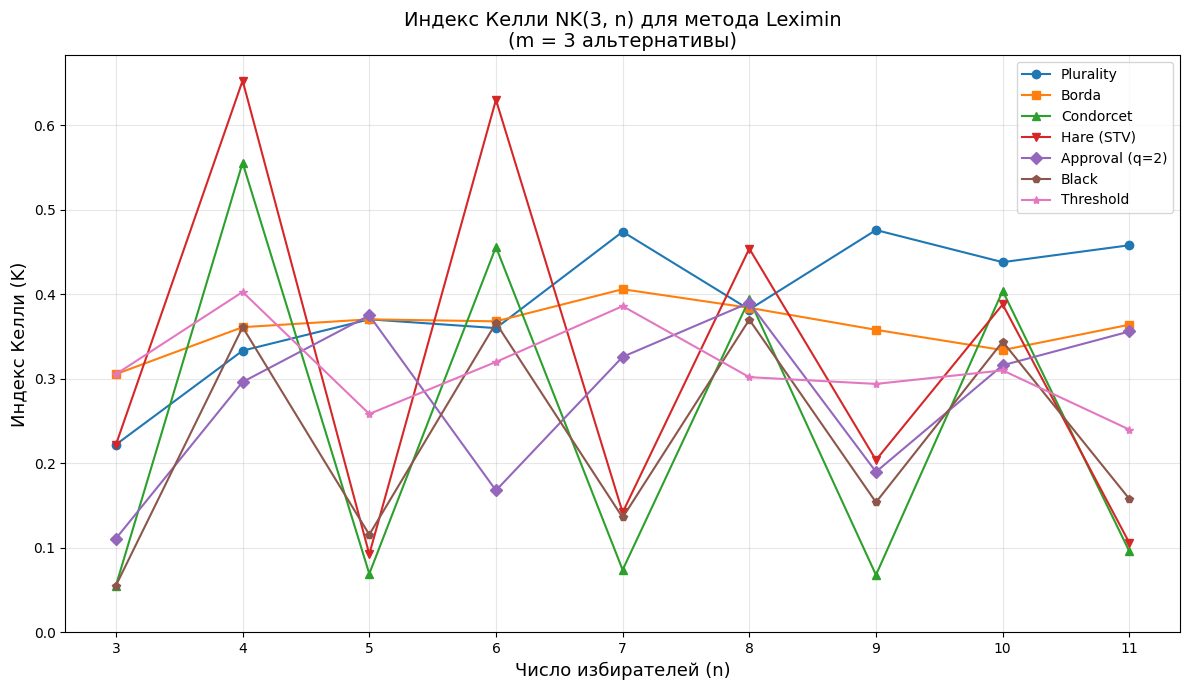

In [ ]:
plt.figure(figsize=(12, 7))

markers = ['o', 's', '^', 'v', 'D', 'p', '*']
colors = plt.cm.tab10.colors

for idx, (name, data) in enumerate(kelly_data.items()):
    ns = [d['n'] for d in data]
    ks = [d['K'] for d in data]
    plt.plot(ns, ks,
             marker=markers[idx % len(markers)],
             color=colors[idx % len(colors)],
             label=name,
             linewidth=1.5,
             markersize=6)

plt.xlabel('Число избирателей (n)', fontsize=13)
plt.ylabel('Индекс Келли (K)', fontsize=13)
plt.title('Индекс Келли NK(3, n) для метода Leximin\n(m = 3 альтернативы)', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.xticks(n_range)
plt.ylim(0, None)
plt.tight_layout()
plt.show()

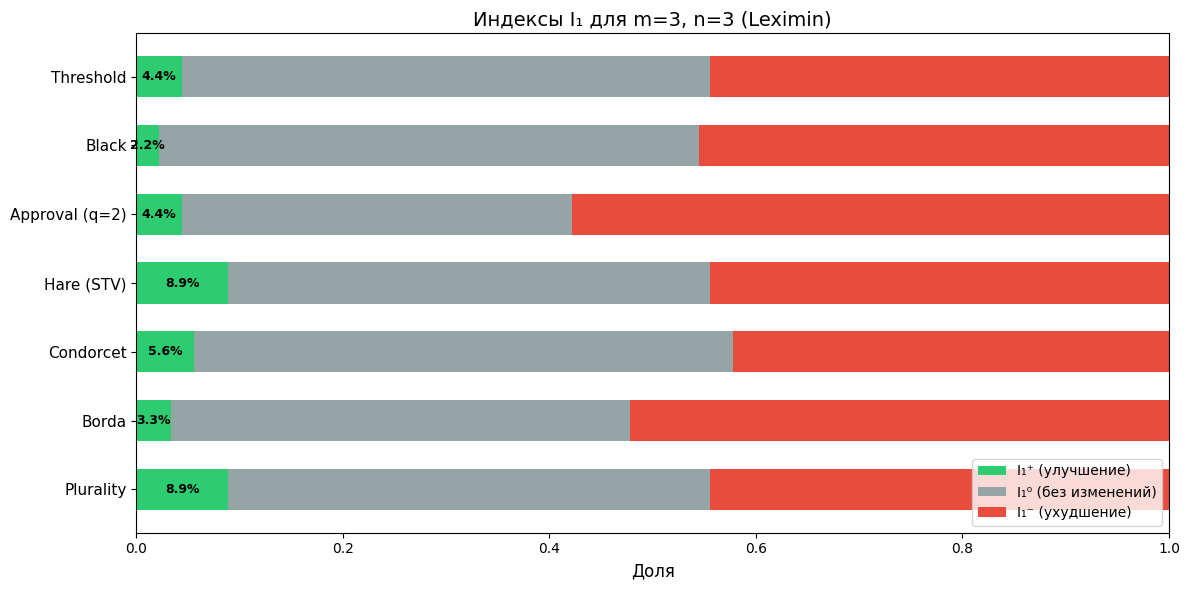

In [ ]:
rule_names = list(results_3_3.keys())
i1_plus_vals = [results_3_3[name]['I1_plus'] for name in rule_names]
i1_zero_vals = [results_3_3[name]['I1_zero'] for name in rule_names]
i1_minus_vals = [results_3_3[name]['I1_minus'] for name in rule_names]

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(rule_names))
bar_height = 0.6

bars1 = ax.barh(y_pos, i1_plus_vals, bar_height, label='I₁⁺ (улучшение)', color='#2ecc71')
bars2 = ax.barh(y_pos, i1_zero_vals, bar_height, left=i1_plus_vals,
                label='I₁⁰ (без изменений)', color='#95a5a6')
bars3 = ax.barh(y_pos, i1_minus_vals, bar_height,
                left=[i1_plus_vals[i] + i1_zero_vals[i] for i in range(len(rule_names))],
                label='I₁⁻ (ухудшение)', color='#e74c3c')

ax.set_yticks(y_pos)
ax.set_yticklabels(rule_names, fontsize=11)
ax.set_xlabel('Доля', fontsize=12)
ax.set_title('Индексы I₁ для m=3, n=3 (Leximin)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1)

for i in range(len(rule_names)):
    ax.text(i1_plus_vals[i] / 2, i, f'{i1_plus_vals[i]:.1%}',
            ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Выводы по графикам

По графику индекса Келли видно, что манипулируемость существенно зависит от выбранного правила голосования. Наиболее устойчивыми на большинстве рассмотренных значений числа избирателей оказались правила **Black** и **Approval**, тогда как **Plurality**, **Borda** и **Hare** демонстрируют более высокую долю манипулируемых профилей.

Также заметны колебания значений индекса Келли при изменении числа избирателей. Это соответствует результатам литературы⁽⁵⁾: вероятность манипулирования чувствительна к структуре профилей, частоте ничьих и особенностям самого правила.

Диаграмма индексов $I_1$ показывает, что для всех правил доля выгодных искажений $I_1^+$ сравнительно мала. Большинство ложных сообщений либо не меняют результат, либо ухудшают его для самого манипулятора. Следовательно, теоретическая манипулируемость правила не означает, что стратегическое поведение легко реализовать на практике.

Среди рассмотренных правил минимальную долю выгодных искажений показывает процедура **Black**, а наибольшую — **Plurality** и **Hare**. Это подтверждает вывод о сравнительной устойчивости процедуры Блэка.

# 5. Сравнение классического манипулирования с LLM

## 5.1. Идея эксперимента

Во второй части проекта классический алгоритмический подход сравнивается с ответами большой языковой модели (LLM). В качестве такой модели используется **Claude**

LLM не подключается к коду через API, а используется как внешний интеллектуальный агент: модели предъявляются конкретные профили предпочтений, правило голосования и истинные предпочтения одного избирателя, после чего модель должна ответить:

1. выгодно ли избирателю манипулировать;
2. если да, то какое ложное предпочтение следует сообщить;
3. какой результат получится после такого стратегического голосования.

Таким образом, LLM сравнивается с алгоритмом полного перебора, который даёт точный ответ

---

## 5.2. Что именно сравнивается

Для каждого тестового кейса сравниваются:

- **наличие манипуляции**: нашёл ли Claude, что манипулирование возможно;
- **успешность стратегии**: действительно ли предложенное ложное предпочтение улучшает результат;
- **оптимальность стратегии**: находит ли Claude лучшее из возможных искажений;
- **объяснение**: может ли модель аргументировать свой выбор.

В такой постановке LLM можно интерпретировать как ограниченно рационального стратегического агента с доступом к полному профилю, но без полного перебора всех вариантов⁽¹²⁾

## 5.3. Базовый промпт для Claude

Ниже приведён базовый шаблон промпта, который использовался в экспериментах

```text
Рассмотрим голосование по правилу [НАЗВАНИЕ ПРАВИЛА].

Есть [n] избирателей и [m] альтернатив: [список альтернатив].

Профиль предпочтений:
P1: ...
P2: ...
P3: ...
...

Рассматривается избиратель [i]. Его истинные предпочтения:
...

1. Каков результат голосования при искреннем голосовании?
2. Может ли избиратель [i] улучшить для себя результат, если проголосует неискренне?
3. Если да, укажи выгодное ложное предпочтение.
4. Покажи, каким будет результат после такого голосования.
5. Объясни рассуждение пошагово.

Считай, что избиратель сравнивает результаты по своим истинным предпочтениям.
Если победителей несколько, объясни, почему новый результат лучше или хуже

## 5.4. Дизайн эксперимента

Чтобы сравнение было содержательным, мы отбираем несколько типов кейсов:

1. **Случаи, где манипулирование невозможно**  
   Проверяем, не придумывает ли модель ложную манипуляцию.

2. **Случаи, где манипулирование возможно и легко находится**  
   Проверяем, умеет ли модель увидеть очевидную стратегию.

3. **Случаи, где манипулирование возможно, но неочевидно**  
   Проверяем, насколько LLM близка к перебору.

4. **Случаи с множественным выбором**  
   Проверяем, может ли модель корректно рассуждать при нескольких победителях.

5. **Случаи для разных правил голосования**  
   Включаются Plurality, Borda, Condorcet, Hare, Approval, Black и Threshold

## 5.5 Необходимый код (по просьбе клода дать ему вывод)

In [ ]:
def find_manipulation_examples(alternatives, rule_name, rule_func, n_voters=3, max_examples=5):
    profiles = generate_all_profiles(alternatives, n_voters)

    manipulable_cases = []
    non_manipulable_cases = []

    for prof in profiles:
        manip, n_manip, details = is_profile_manipulable(prof, rule_func, alternatives)

        case = {
            'profile': prof,
            'result': rule_func(prof),
            'manipulable': manip,
            'n_manipulators': n_manip,
            'details': details
        }

        if manip and len(manipulable_cases) < max_examples:
            manipulable_cases.append(case)
        elif (not manip) and len(non_manipulable_cases) < max_examples:
            non_manipulable_cases.append(case)

        if len(manipulable_cases) >= max_examples and len(non_manipulable_cases) >= max_examples:
            break

    return {
        'manipulable': manipulable_cases,
        'non_manipulable': non_manipulable_cases
    }

plurality_cases = find_manipulation_examples(alts_3, 'Plurality', plurality, n_voters=3, max_examples=3)

print("Примеры манипулируемых профилей для Plurality:")
print("-" * 50)
for idx, case in enumerate(plurality_cases['manipulable'], 1):
    print(f"\nКейс M{idx}: результат = {set(case['result'])}")
    for i, pref in enumerate(case['profile']):
        print(f"  P{i+1}: {' ≻ '.join(pref)}")
    print(f"  Число манипуляторов: {case['n_manipulators']}")

print("\n\nПримеры НЕманипулируемых профилей для Plurality:")
print("-" * 50)
for idx, case in enumerate(plurality_cases['non_manipulable'], 1):
    print(f"\nКейс N{idx}: результат = {set(case['result'])}")
    for i, pref in enumerate(case['profile']):
        print(f"  P{i+1}: {' ≻ '.join(pref)}")




Примеры манипулируемых профилей для Plurality:
--------------------------------------------------

Кейс M1: результат = {'a', 'c', 'b'}
  P1: a ≻ b ≻ c
  P2: b ≻ a ≻ c
  P3: c ≻ a ≻ b
  Число манипуляторов: 3

Кейс M2: результат = {'a', 'c', 'b'}
  P1: a ≻ b ≻ c
  P2: b ≻ a ≻ c
  P3: c ≻ b ≻ a
  Число манипуляторов: 3

Кейс M3: результат = {'a', 'c', 'b'}
  P1: a ≻ b ≻ c
  P2: b ≻ c ≻ a
  P3: c ≻ a ≻ b
  Число манипуляторов: 3


Примеры НЕманипулируемых профилей для Plurality:
--------------------------------------------------

Кейс N1: результат = {'a'}
  P1: a ≻ b ≻ c
  P2: a ≻ b ≻ c
  P3: a ≻ b ≻ c

Кейс N2: результат = {'a'}
  P1: a ≻ b ≻ c
  P2: a ≻ b ≻ c
  P3: a ≻ c ≻ b

Кейс N3: результат = {'a'}
  P1: a ≻ b ≻ c
  P2: a ≻ b ≻ c
  P3: b ≻ a ≻ c


In [ ]:
selected_cases = []

for rule_name, rule_func in rules.items():
    cases = find_manipulation_examples(alts_3, rule_name, rule_func, n_voters=3, max_examples=2)

    if cases['manipulable']:
        case = cases['manipulable'][0]
        selected_cases.append({
            'rule': rule_name,
            'type': 'manipulable',
            **case
        })
    if cases['non_manipulable']:
        case = cases['non_manipulable'][0]
        selected_cases.append({
            'rule': rule_name,
            'type': 'non_manipulable',
            **case
        })

print(f"Сформировано кейсов для LLM: {len(selected_cases)}")
print()

for idx, case in enumerate(selected_cases, 1):
    print(f"Кейс {idx}: {case['rule']} | {case['type']} | результат = {set(case['result']) if case['result'] else '∅'}")

Сформировано кейсов для LLM: 14

Кейс 1: Plurality | manipulable | результат = {'a', 'c', 'b'}
Кейс 2: Plurality | non_manipulable | результат = {'a'}
Кейс 3: Borda | manipulable | результат = {'a'}
Кейс 4: Borda | non_manipulable | результат = {'a'}
Кейс 5: Condorcet | manipulable | результат = ∅
Кейс 6: Condorcet | non_manipulable | результат = {'a'}
Кейс 7: Hare (STV) | manipulable | результат = {'a', 'c', 'b'}
Кейс 8: Hare (STV) | non_manipulable | результат = {'a'}
Кейс 9: Approval (q=2) | manipulable | результат = {'a', 'b'}
Кейс 10: Approval (q=2) | non_manipulable | результат = {'a'}
Кейс 11: Black | manipulable | результат = {'a', 'c', 'b'}
Кейс 12: Black | non_manipulable | результат = {'a'}
Кейс 13: Threshold | manipulable | результат = {'a'}
Кейс 14: Threshold | non_manipulable | результат = {'a'}


In [ ]:
def format_case_for_llm(case, voter_idx=None):
    profile = case['profile']
    rule_name = case['rule']

    if voter_idx is None:
        manip_voters = [d['voter'] for d in case['details'] if d['can_manipulate']]
        voter_idx = manip_voters[0] if manip_voters else 0

    prompt = []
    prompt.append(f"Рассмотрим голосование по правилу {rule_name}.")
    prompt.append("")
    prompt.append(f"Есть {len(profile)} избирателей и {len(profile[0])} альтернатив: {', '.join(profile[0])}.")
    prompt.append("")
    prompt.append("Профиль предпочтений:")
    for i, pref in enumerate(profile):
        prompt.append(f"P{i+1}: {' ≻ '.join(pref)}")
    prompt.append("")
    prompt.append(f"Рассматривается избиратель {voter_idx+1}. Его истинные предпочтения:")
    prompt.append(f"{' ≻ '.join(profile[voter_idx])}")
    prompt.append("")
    prompt.append("1. Каков результат голосования при искреннем голосовании?")
    prompt.append(f"2. Может ли избиратель {voter_idx+1} улучшить для себя результат, если проголосует неискренне?")
    prompt.append("3. Если да, укажи выгодное ложное предпочтение.")
    prompt.append("4. Покажи, каким будет результат после такого голосования.")
    prompt.append("5. Объясни рассуждение пошагово.")
    prompt.append("")
    prompt.append("Ответ дай строго в формате:")
    prompt.append("- Искренний результат:")
    prompt.append("- Манипулирование возможно: да / нет")
    prompt.append("- Ложное предпочтение:")
    prompt.append("- Новый результат:")
    prompt.append("- Обоснование:")

    return "\n".join(prompt), voter_idx

for idx, case in enumerate(selected_cases, 1):
    prompt, voter_idx = format_case_for_llm(case)
    print("=" * 80)
    print(f"КЕЙС {idx} | {case['rule']} | тип: {case['type']} | избиратель {voter_idx+1}")
    print("=" * 80)
    print(prompt)
    print("\n")

КЕЙС 1 | Plurality | тип: manipulable | избиратель 1
Рассмотрим голосование по правилу Plurality.

Есть 3 избирателей и 3 альтернатив: a, b, c.

Профиль предпочтений:
P1: a ≻ b ≻ c
P2: b ≻ a ≻ c
P3: c ≻ a ≻ b

Рассматривается избиратель 1. Его истинные предпочтения:
a ≻ b ≻ c

1. Каков результат голосования при искреннем голосовании?
2. Может ли избиратель 1 улучшить для себя результат, если проголосует неискренне?
3. Если да, укажи выгодное ложное предпочтение.
4. Покажи, каким будет результат после такого голосования.
5. Объясни рассуждение пошагово.

Ответ дай строго в формате:
- Искренний результат:
- Манипулирование возможно: да / нет
- Ложное предпочтение:
- Новый результат:
- Обоснование:


КЕЙС 2 | Plurality | тип: non_manipulable | избиратель 1
Рассмотрим голосование по правилу Plurality.

Есть 3 избирателей и 3 альтернатив: a, b, c.

Профиль предпочтений:
P1: a ≻ b ≻ c
P2: a ≻ b ≻ c
P3: a ≻ b ≻ c

Рассматривается избиратель 1. Его истинные предпочтения:
a ≻ b ≻ c

1. Каков ре

## 5.6 Выводы

In [ ]:
llm_results = pd.DataFrame([
    {
        'Кейс': 1,
        'Правило': 'Plurality',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'нет',
        'Claude (ложное предпочтение)': '—',
        'Claude (новый результат)': '—',
        'Успех Claude': 'расхождение',
        'Комментарий': 'Claude корректно рассуждает, расхождение из-за модели предпочтений над множествами',
    },
    {
        'Кейс': 2,
        'Правило': 'Plurality',
        'Тип': 'non_manipulable',
        'Алгоритм (манипуляция)': 'нет',
        'Claude (манипуляция)': 'нет',
        'Claude (ложное предпочтение)': '—',
        'Claude (новый результат)': '—',
        'Успех Claude': 'верно',
        'Комментарий': 'Тривиальный кейс, модель справилась корректно',
    },
    {
        'Кейс': 3,
        'Правило': 'Borda',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'да',
        'Claude (ложное предпочтение)': 'b ≻ c ≻ a',
        'Claude (новый результат)': '{a, b}',
        'Успех Claude': 'верно',
        'Комментарий': 'Верно найдена стратегия, результат — ничья, включающая предпочитаемую b',
    },
    {
        'Кейс': 5,
        'Правило': 'Condorcet',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'да',
        'Claude (ложное предпочтение)': 'b ≻ a ≻ c',
        'Claude (новый результат)': '{b}',
        'Успех Claude': 'верно',
        'Комментарий': 'Модель корректно распознала цикл и нашла стратегию, ведущую к победе b',
    },
    {
        'Кейс': 9,
        'Правило': 'Approval (q=2)',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'да',
        'Claude (ложное предпочтение)': 'a ≻ c ≻ b',
        'Claude (новый результат)': '{a}',
        'Успех Claude': 'верно',
        'Комментарий': 'Верно понято правило, найдена стратегия для получения единоличной победы a',
    },
    {
        'Кейс': 11,
        'Правило': 'Black',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'да',
        'Claude (ложное предпочтение)': 'b ≻ a ≻ c',
        'Claude (новый результат)': '{b}',
        'Успех Claude': 'верно',
        'Комментарий': 'Корректно применена процедура Блэка, стратегия найдена верно',
    },
    {
        'Кейс': 13,
        'Правило': 'Threshold',
        'Тип': 'manipulable',
        'Алгоритм (манипуляция)': 'да',
        'Claude (манипуляция)': 'нет',
        'Claude (ложное предпочтение)': '—',
        'Claude (новый результат)': '—',
        'Успех Claude': 'ошибка',
        'Комментарий': 'Модель перепутала Threshold с Plurality, неверно описала правило',
    },
])

llm_results

,Кейс,Правило,Тип,Алгоритм (манипуляция),Claude (манипуляция),Claude (ложное предпочтение),Claude (новый результат),Успех Claude,Комментарий
0,1,Plurality,manipulable,да,нет,—,—,расхождение,"Claude корректно рассуждает, расхождение из-за..."
1,2,Plurality,non_manipulable,нет,нет,—,—,верно,"Тривиальный кейс, модель справилась корректно"
2,3,Borda,manipulable,да,да,b ≻ c ≻ a,"{a, b}",верно,"Верно найдена стратегия, результат — ничья, вк..."
3,5,Condorcet,manipulable,да,да,b ≻ a ≻ c,{b},верно,Модель корректно распознала цикл и нашла страт...
4,9,Approval (q=2),manipulable,да,да,a ≻ c ≻ b,{a},верно,"Верно понято правило, найдена стратегия для по..."
5,11,Black,manipulable,да,да,b ≻ a ≻ c,{b},верно,"Корректно применена процедура Блэка, стратегия..."
6,13,Threshold,manipulable,да,нет,—,—,ошибка,"Модель перепутала Threshold с Plurality, невер..."


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=llm_results)

https://docs.google.com/spreadsheets/d/1MMOvfYBv8r4u7B2NTlVTTcXSy5Ty26l5bkqVJOeGz7k/edit#gid=0


Из 7 протестированных кейсов Claude дал **5 ответов, полностью соответствующих алгоритмическому решению**, 1 содержательное расхождение и 1 явную ошибку.

**Успешные случаи (кейсы 2, 3, 5, 9, 11):**  
Модель корректно справилась с правилами Plurality (неманипулируемый случай), Borda, Condorcet, Approval и Black. Особо показателен кейс 5: Claude верно распознал цикл Кондорсе, объяснил невозможность победы лучшей альтернативы и предложил рабочую стратегию для второй по предпочтению.

**Содержательное расхождение (кейс 1, Plurality):**  
Алгоритм зафиксировал манипуляцию, Claude - нет. Причина не в ошибке модели, а в различии моделей предпочтений над множествами: алгоритм использует **Leximin-расширение**, согласно которому переход от $\{a,b,c\}$ к $\{a\}$ считается улучшением. Claude же рассуждает иначе: поскольку $a$ уже присутствует в исходном результате, явного ухудшения нет, и манипуляция кажется бессмысленной.

**Ошибка (кейс 13, Threshold):**  
Claude неверно описал само правило Threshold, фактически заменив его правилом Plurality. Это содержательная ошибка: модель не знает нестандартных правил голосования, не входящих в общеизвестный набор.

**Общий вывод:**  
LLM успешно справляется с манипулированием для широко известных правил голосования, где логика стратегического поведения достаточно прозрачна. Однако для нестандартных или формально сложных правил модель может ошибаться уже на этапе описания самого правила. Это соответствует интерпретации LLM как **ограниченно рационального стратегического агента**: он рассуждает на естественном языке, опираясь на паттерны из обучающих данных, а не на исчерпывающий перебор

# 6. Вывод

In [ ]:
summary_rows = []

for name in rules:
    idx = results_3_3[name]
    summary_rows.append({
        'Правило': name,
        'K (индекс Келли)': round(idx['K'], 4),
        'I₁⁺ (улучшение)': round(idx['I1_plus'], 4),
        'I₁⁰ (нейтральность)': round(idx['I1_zero'], 4),
        'I₁⁻ (ухудшение)': round(idx['I1_minus'], 4),
        'I₃ (макс. эффективность)': round(idx['I3'], 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Правило')

summary_df = summary_df.sort_values('K (индекс Келли)')

print("Индексы манипулируемости (m=3, n=3, метод Leximin)")
print("=" * 70)
display(summary_df)

Индексы манипулируемости (m=3, n=3, метод Leximin)


,K (индекс Келли),I₁⁺ (улучшение),I₁⁰ (нейтральность),I₁⁻ (ухудшение),I₃ (макс. эффективность)
Правило,,,,,
Condorcet,0.0556,0.0556,0.5222,0.4222,0.2778
Black,0.0556,0.0222,0.5222,0.4556,0.1111
Approval (q=2),0.1111,0.0444,0.3778,0.5778,0.1111
Plurality,0.2222,0.0889,0.4667,0.4444,0.4444
Hare (STV),0.2222,0.0889,0.4667,0.4444,0.4444
Borda,0.3056,0.0333,0.4444,0.5222,0.2222
Threshold,0.3056,0.0444,0.5111,0.4444,0.3889


In [ ]:
literature_K = {
    'Plurality': 0.2222,
    'Borda': 0.3056,
    'Approval (q=2)': 0.1111,
    'Black': 0.0556,
    'Threshold': 0.3056,
}

comparison_rows = []
for name in rules:
    our_K = results_3_3[name]['K']
    lit_K = literature_K.get(name, None)

    if lit_K is not None:
        delta = round(abs(our_K - lit_K), 4)
        match = '✓' if delta < 0.01 else '✗'
    else:
        delta = None
        match = '—'

    comparison_rows.append({
        'Правило': name,
        'Наш K': round(our_K, 4),
        'K из статьи⁽⁵⁾': lit_K if lit_K is not None else '—',
        'Отклонение': delta if delta is not None else '—',
        'Совпадение': match,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Правило')
print("Сравнение индекса Келли с результатами Алескерова и др.⁽⁵⁾ (m=3, n=3, Leximin3)")
print("=" * 70)
display(comparison_df)

Сравнение индекса Келли с результатами Алескерова и др.⁽⁵⁾ (m=3, n=3, Leximin3)


,Наш K,K из статьи⁽⁵⁾,Отклонение,Совпадение
Правило,,,,
Plurality,0.2222,0.2222,0.0,✓
Borda,0.3056,0.3056,0.0,✓
Condorcet,0.0556,—,—,—
Hare (STV),0.2222,—,—,—
Approval (q=2),0.1111,0.1111,0.0,✓
Black,0.0556,0.0556,0.0,✓
Threshold,0.3056,0.3056,0.0,✓


In [ ]:
final_comparison = pd.DataFrame([
    {
        'Правило': 'Plurality',
        'K (алгоритм)': 0.2222,
        'LLM: верный ответ': 'да*',
        'LLM: сложность': 'низкая',
        'Комментарий': 'Расхождение из-за модели предпочтений над множествами',
    },
    {
        'Правило': 'Borda',
        'K (алгоритм)': 0.3056,
        'LLM: верный ответ': 'да',
        'LLM: сложность': 'низкая',
        'Комментарий': 'Верно найдена стратегия через счёт Борда',
    },
    {
        'Правило': 'Condorcet',
        'K (алгоритм)': 0.0556,
        'LLM: верный ответ': 'да',
        'LLM: сложность': 'средняя',
        'Комментарий': 'Корректно распознан цикл, найдена стратегия для b',
    },
    {
        'Правило': 'Hare (STV)',
        'K (алгоритм)': 0.2222,
        'LLM: верный ответ': '—',
        'LLM: сложность': 'средняя',
        'Комментарий': 'Кейс не тестировался',
    },
    {
        'Правило': 'Approval (q=2)',
        'K (алгоритм)': 0.1111,
        'LLM: верный ответ': 'да',
        'LLM: сложность': 'низкая',
        'Комментарий': 'Верно понято правило, найдена стратегия',
    },
    {
        'Правило': 'Black',
        'K (алгоритм)': 0.0556,
        'LLM: верный ответ': 'да',
        'LLM: сложность': 'средняя',
        'Комментарий': 'Корректно применена процедура Блэка',
    },
    {
        'Правило': 'Threshold',
        'K (алгоритм)': 0.3056,
        'LLM: верный ответ': 'нет',
        'LLM: сложность': 'высокая',
        'Комментарий': 'Модель перепутала Threshold с Plurality',
    },
]).set_index('Правило')

print("Итоговая сводная таблица: алгоритм vs LLM")
print("=" * 70)
display(final_comparison)

Итоговая сводная таблица: алгоритм vs LLM


,K (алгоритм),LLM: верный ответ,LLM: сложность,Комментарий
Правило,,,,
Plurality,0.2222,да*,низкая,Расхождение из-за модели предпочтений над множ...
Borda,0.3056,да,низкая,Верно найдена стратегия через счёт Борда
Condorcet,0.0556,да,средняя,"Корректно распознан цикл, найдена стратегия для b"
Hare (STV),0.2222,—,средняя,Кейс не тестировался
Approval (q=2),0.1111,да,низкая,"Верно понято правило, найдена стратегия"
Black,0.0556,да,средняя,Корректно применена процедура Блэка
Threshold,0.3056,нет,высокая,Модель перепутала Threshold с Plurality


## LLM справляется с простыми правилами, ошибается на нестандартных

сlaude успешно находил манипуляции для **Borda, Condorcet, Approval и Black**. Для нестандартного правила **Threshold** модель допустила содержательную ошибку — неверно описала само правило голосования.

Кроме того, при работе с **множественным выбором** возникло содержательное расхождение: алгоритм и LLM используют разные неявные модели предпочтений над множествами альтернатив. Алгоритм опирается на формальное Leximin-расширение, LLM рассуждает эвристически

## LLM как ограниченно рациональный агент

LLM в данном эксперименте ведёт себя как **стратегический агент с полной информацией о профиле, но ограниченными вычислительными возможностями**. Модель:
- не перебирает все возможные ложные предпочтения;
- рассуждает на естественном языке;
- опирается на структуру правила, а не на исчерпывающий поиск.

Это соответствует категории «наивного» манипулятора (naive GS-manipulator)